In [20]:
import random

def gibbs_sampler_beta_binomial(n, y, alpha_prior, beta_prior, n_iter=10000):
    # Initial values
    p = 0.5
    samples = []

    for i in range(n_iter):
        # Sample p from the Beta posterior
        alpha_post = y + alpha_prior
        beta_post = n - y + beta_prior
        p = random.betavariate(alpha_post, beta_post)
        samples.append(p)

    return samples

# Test
n = 100  # Number of trials
y = 70   # Number of successes
alpha_prior = 2
beta_prior = 2
samples = gibbs_sampler_beta_binomial(n, y, alpha_prior, beta_prior)


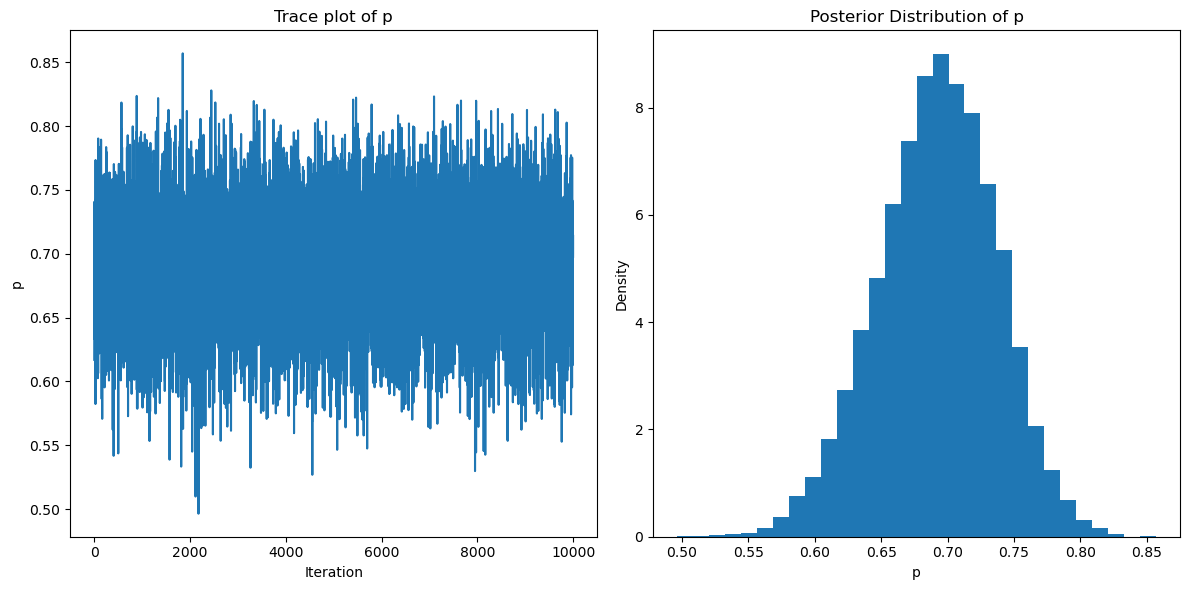

In [21]:
import matplotlib.pyplot as plt

def plot_beta_binomial(samples):
    # Convergence (Trace Plot)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(samples)
    plt.title("Trace plot of p")
    plt.xlabel("Iteration")
    plt.ylabel("p")

    # Posterior Distribution
    plt.subplot(1, 2, 2)
    plt.hist(samples, bins=30, density=True)
    plt.title("Posterior Distribution of p")
    plt.xlabel("p")
    plt.ylabel("Density")
    
    plt.tight_layout()
    plt.show()

# Using the samples from our previous example
plot_beta_binomial(samples)


[-0.55534977  1.85520738]


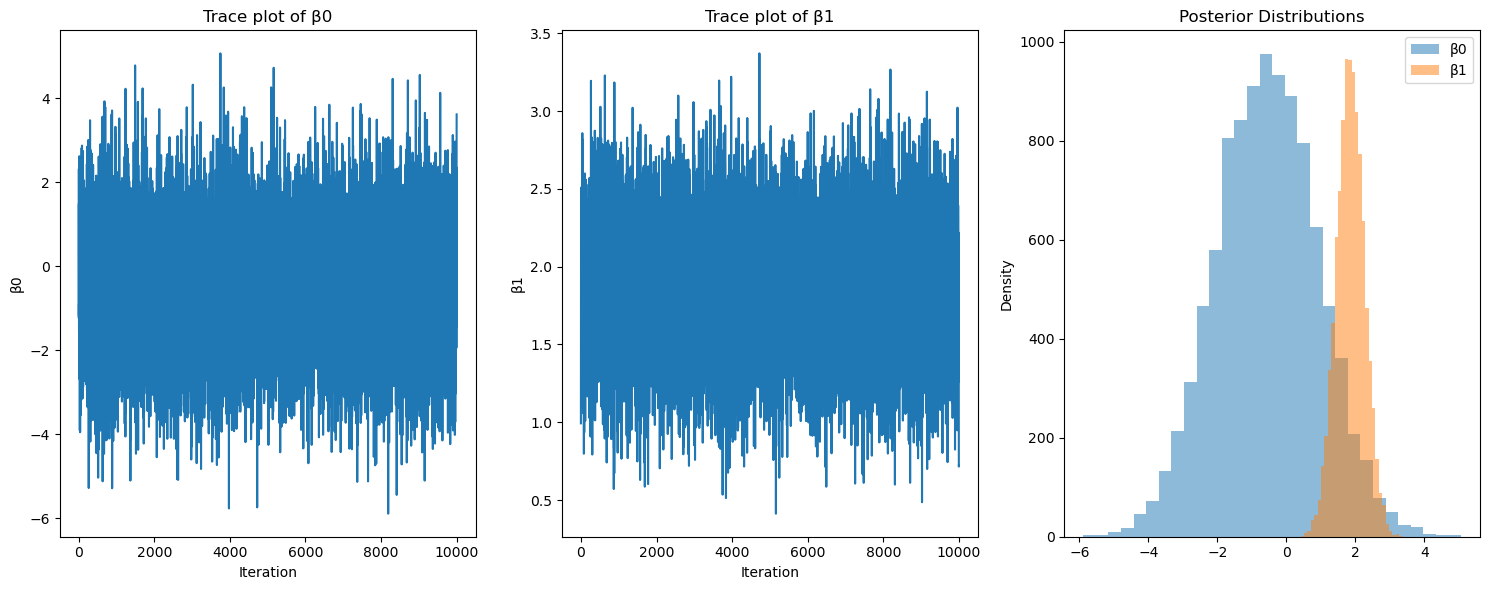

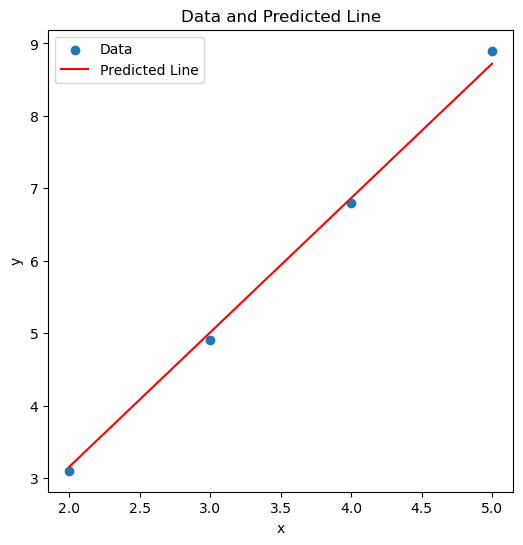

In [23]:
import numpy as np

def gibbs_sampler_linear_regression(X, y, sigma2, sigma2_prior, n_iter=10000):
    n, p = X.shape
    beta = np.zeros(p)
    samples = []

    XTX = np.dot(X.T, X)
    XTy = np.dot(X.T, y)

    for i in range(n_iter):
        # Calculate the posterior variance and mean for beta
        Sigma_post = np.linalg.inv(XTX / sigma2 + np.eye(p) / sigma2_prior)
        mu_post = np.dot(Sigma_post, XTy / sigma2)  # Corrected line

        # Sample beta from its multivariate normal posterior
        beta = np.random.multivariate_normal(mu_post, Sigma_post)
        samples.append(beta)

    return np.array(samples)

# Test
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
y = np.array([3.1, 4.9, 6.8, 8.9])
sigma2 = 1
sigma2_prior = np.array([10, 10])
samples = gibbs_sampler_linear_regression(X, y, sigma2, sigma2_prior)

# Analyze the samples, for example by computing the mean:
mean_beta_samples = samples.mean(axis=0)
print(mean_beta_samples)

def plot_linear_regression(X, y, samples):
    mean_beta = samples.mean(axis=0)
    
    plt.figure(figsize=(15, 6))
    
    # Convergence (Trace Plot)
    plt.subplot(1, 3, 1)
    plt.plot(samples[:, 0])
    plt.title("Trace plot of β0")
    plt.xlabel("Iteration")
    plt.ylabel("β0")
    
    plt.subplot(1, 3, 2)
    plt.plot(samples[:, 1])
    plt.title("Trace plot of β1")
    plt.xlabel("Iteration")
    plt.ylabel("β1")
    
    # Posterior Distributions
    plt.subplot(1, 3, 3)
    plt.hist(samples[:, 0], bins=30, alpha=0.5, label="β0")
    plt.hist(samples[:, 1], bins=30, alpha=0.5, label="β1")
    plt.title("Posterior Distributions")
    plt.ylabel("Density")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Prediction
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 1], y, label="Data")
    plt.plot(X[:, 1], X @ mean_beta, 'r', label="Predicted Line")
    plt.title("Data and Predicted Line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

# Using the X, y, and samples from our previous example
plot_linear_regression(X, y, samples)



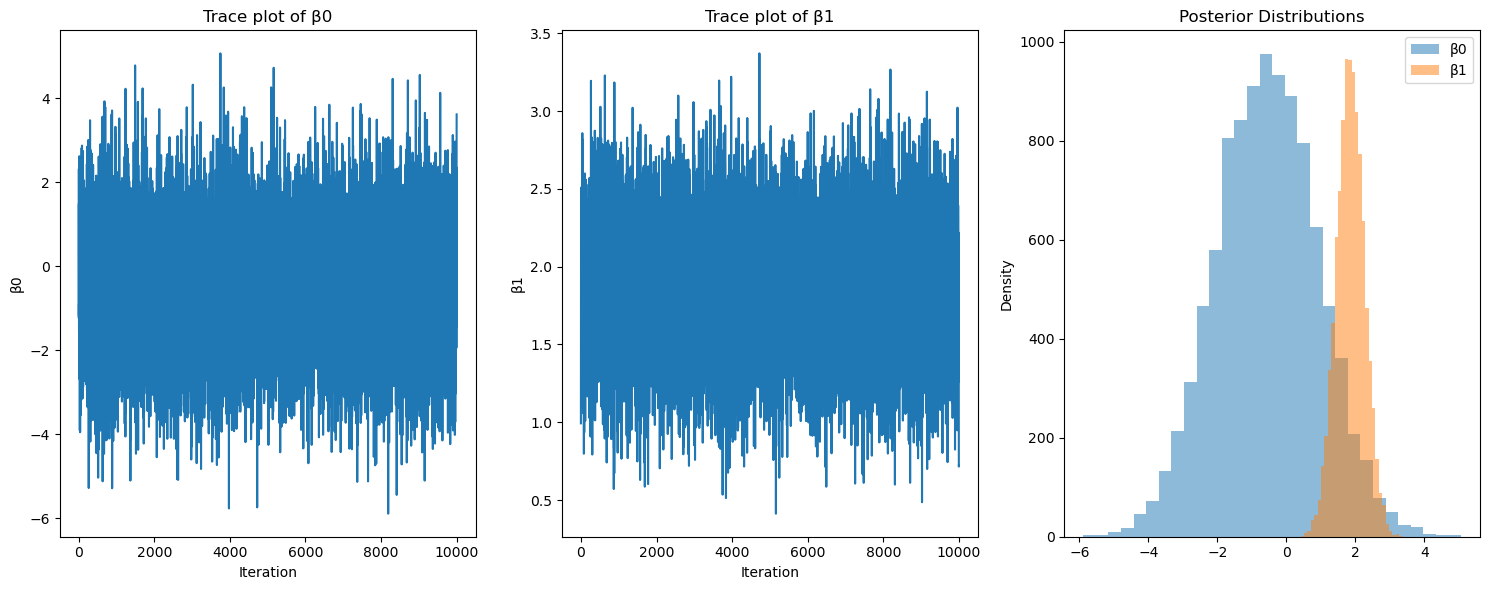

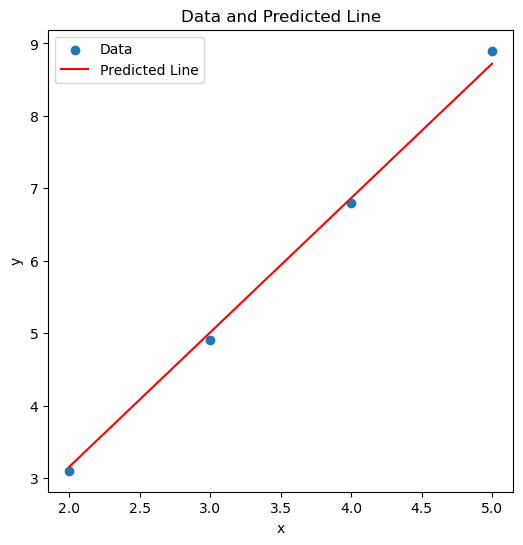

In [24]:
def plot_linear_regression(X, y, samples):
    mean_beta = samples.mean(axis=0)
    
    plt.figure(figsize=(15, 6))
    
    # Convergence (Trace Plot)
    plt.subplot(1, 3, 1)
    plt.plot(samples[:, 0])
    plt.title("Trace plot of β0")
    plt.xlabel("Iteration")
    plt.ylabel("β0")
    
    plt.subplot(1, 3, 2)
    plt.plot(samples[:, 1])
    plt.title("Trace plot of β1")
    plt.xlabel("Iteration")
    plt.ylabel("β1")
    
    # Posterior Distributions
    plt.subplot(1, 3, 3)
    plt.hist(samples[:, 0], bins=30, alpha=0.5, label="β0")
    plt.hist(samples[:, 1], bins=30, alpha=0.5, label="β1")
    plt.title("Posterior Distributions")
    plt.ylabel("Density")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Prediction
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 1], y, label="Data")
    plt.plot(X[:, 1], X @ mean_beta, 'r', label="Predicted Line")
    plt.title("Data and Predicted Line")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

# Using the X, y, and samples from our previous example
plot_linear_regression(X, y, samples)


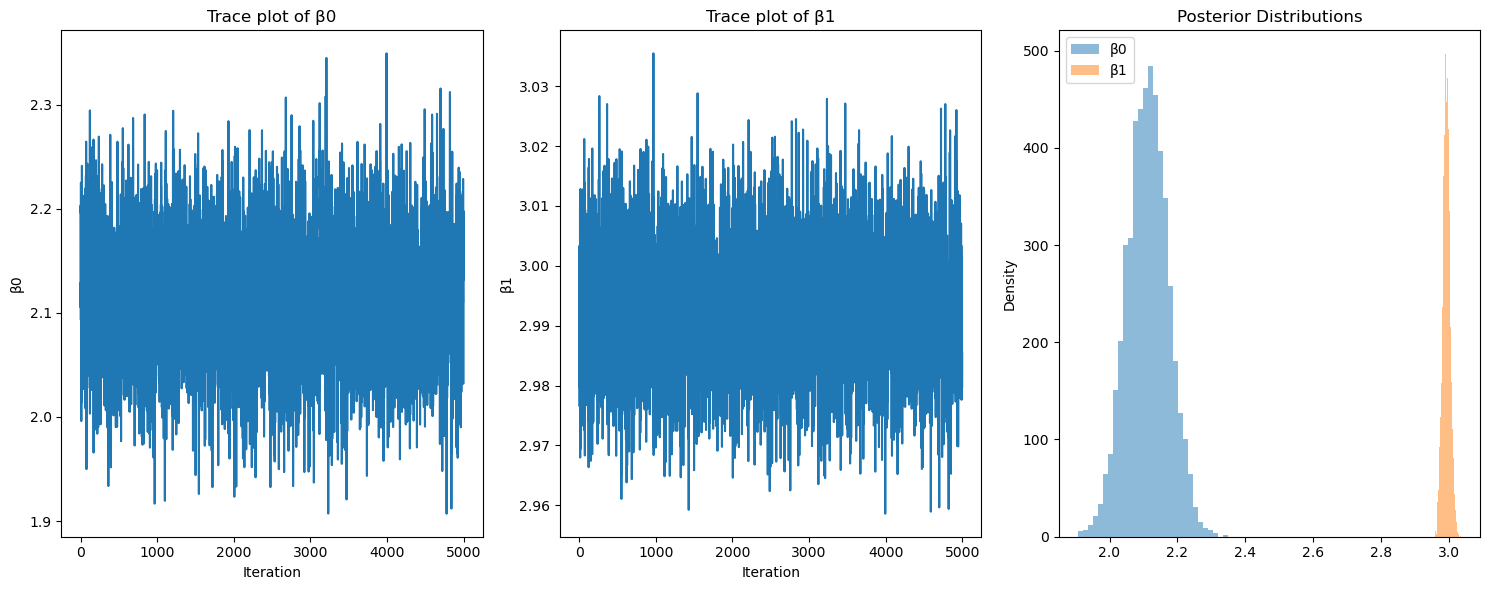

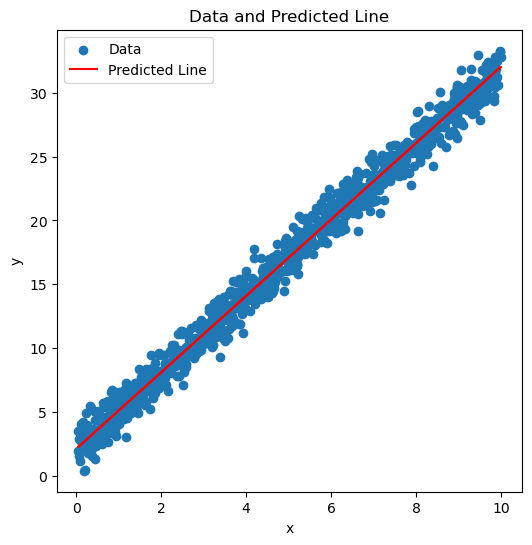

In [25]:
# Generate data
np.random.seed(42)  # for reproducibility

n_samples = 1000
x = np.random.uniform(0, 10, n_samples)
epsilon = np.random.normal(0, 1, n_samples)

# True coefficients: beta_0 = 2, beta_1 = 3
y = 2 + 3 * x + epsilon
sigma2_prior = np.array([0.1, 0.1])
# Add intercept to X for regression
X_large = np.column_stack([np.ones(n_samples), x])

# Use our Gibbs sampler for the larger dataset
samples_large = gibbs_sampler_linear_regression(X_large, y, sigma2, sigma2_prior, n_iter=5000)

# Plot results
plot_linear_regression(X_large, y, samples_large)


## Cálculo del Factor de Bayes en Regresión Lineal

El Factor de Bayes es una medida bayesiana que se utiliza para comparar modelos estadísticos. En el contexto de la regresión lineal, a menudo comparamos un modelo nulo (que podría incluir solo el término de intercepción) con un modelo alternativo (que incluye uno o más predictores).

Para calcular el Factor de Bayes, seguimos los siguientes pasos:

Paso 1: Ajustar ambos modelos y encontrar las estimaciones MAP

Primero ajustamos ambos modelos y buscamos las estimaciones de máxima a posteriori (MAP) de los parámetros. En nuestro caso simplificado, utilizamos las estimaciones de máxima verosimilitud (MLE) como una aproximación de las MAP, bajo la suposición de que tenemos priors uniformes.

Paso 2: Calcular la matriz de Hessiano en las estimaciones MAP

El Hessiano es una matriz de segundas derivadas que utilizamos para estimar la varianza alrededor de las estimaciones MAP.

Paso 3: Calcular la verosimilitud marginal

Usando la aproximación de Laplace, calculamos la verosimilitud marginal para ambos modelos. La verosimilitud marginal se obtiene integrando el producto de la verosimilitud y la prior sobre todos los parámetros posibles.

Paso 4: Calcular el Factor de Bayes

Finalmente, calculamos el Factor de Bayes como la razón entre las verosimilitudes marginales de los dos modelos.

El Factor de Bayes nos indica la fuerza de la evidencia a favor de un modelo sobre otro. Un Factor de Bayes mayor que 1 favorece el modelo alternativo, mientras que un valor menor que 1 favorece el modelo nulo.

# Cálculo del Factor de Bayes en Regresión Lineal

## Conceptos Básicos

El Factor de Bayes (BF) es una herramienta de la estadística bayesiana para comparar dos modelos, denotados como $ M_0 $ (el modelo nulo) y $ M_1 $ (el modelo alternativo o completo). Matemáticamente, el Factor de Bayes se define como la razón entre las probabilidades marginales de los datos bajo cada modelo:

$ BF_{10} = \frac{P(\text{Datos} | M_1)}{P(\text{Datos} | M_0)} $

## Aproximación de Laplace

La probabilidad marginal de los datos, $ P(\text{Datos} | M) $, es difícil de calcular directamente porque requiere integrar el producto de la verosimilitud y la prior sobre todo el espacio de parámetros. La aproximación de Laplace nos permite estimar esta probabilidad marginal de una manera más manejable.

### 1. Estimaciones de Máxima A Posteriori (MAP)

Primero encontramos las estimaciones MAP, $ \hat{\beta}_{MAP}$, que maximizan la posterior $ P(\beta | \text{Datos}, M) $:

$ \hat{\beta}_{MAP} = \arg \max_\beta P(\beta | \text{Datos}, M) $

### 2. Hessiano en las Estimaciones MAP

El Hessiano $ H $ en $ \hat{\beta}_{MAP} $ es la matriz de las segundas derivadas del negativo del logaritmo de la posterior:

$ H = -\nabla^2 \log P(\beta | \text{Datos}, M) \big|_{\beta = \hat{\beta}_{MAP}} $

La inversa del Hessiano nos da la matriz de covarianza aproximada de los parámetros:

$ \Sigma \approx H^{-1} $

### 3. Logaritmo de la Verosimilitud Marginal Aproximada

El logaritmo de la verosimilitud marginal aproximada bajo la aproximación de Laplace se calcula como:

$ \log P(\text{Datos} | M) \approx \log P(\text{Datos} | \hat{\beta}_{MAP}, M) - \frac{1}{2} \log |\Sigma| - \frac{p}{2} \log(2\pi) $

donde $ p $ es el número de parámetros y $ |\Sigma| $ es el determinante de la matriz de covarianza.

### 4. Factor de Bayes

El Factor de Bayes se obtiene al tomar la diferencia entre las verosimilitudes marginales logarítmicas de los modelos alternativo y nulo:

$ BF_{10} = \exp(\log P(\text{Datos} | M_1) - \log P(\text{Datos} | M_0)) $

Si $ BF_{10} > 1 $, la evidencia favorece al modelo $ M_1 $, mientras que si $ BF_{10} < 1 $, favorece al modelo $ M_0 $.






In [7]:
import numpy as np

# Sample data
X = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])  # Design matrix with an intercept and one predictor
y = np.array([3.1, 4.9, 6.8, 8.9])              # Response variable

# Null model with only intercept
X_null = X[:, [0]]  # Keep only the intercept column

# Full model with intercept and predictor
X_full = X          # Full design matrix with intercept and predictor

# Assuming some known variance for the error term, for example:
sigma2 = 1




In [8]:
from scipy.optimize import minimize
from scipy.stats import norm

# Assuming X_null only contains the intercept and X_full contains the intercept and predictors
def negative_log_likelihood_null(beta_null):
    # Predict using the null model
    y_pred = X_null @ beta_null
    # Compute the negative log likelihood
    return -np.sum(norm.logpdf(y, loc=y_pred, scale=np.sqrt(sigma2)))

def negative_log_likelihood_full(beta_full):
    # Predict using the full model
    y_pred = X_full @ beta_full
    # Compute the negative log likelihood
    return -np.sum(norm.logpdf(y, loc=y_pred, scale=np.sqrt(sigma2)))

# Initial guess for betas (can use zeros or small random values)
initial_guess_null = np.zeros(X_null.shape[1])
initial_guess_full = np.zeros(X_full.shape[1])

# Find the MAP estimates
res_null = minimize(negative_log_likelihood_null, initial_guess_null)
res_full = minimize(negative_log_likelihood_full, initial_guess_full)

# Extract the MAP estimates
beta_map_null = res_null.x
beta_map_full = res_full.x


In [9]:
from scipy.linalg import det

# Function to compute the Hessian matrix of the negative log likelihood
def hessian_neg_log_likelihood(beta_hat, X, sigma2):
    return X.T @ X / sigma2

# Compute the Hessians for both models at the MAP estimates
hessian_null = hessian_neg_log_likelihood(beta_map_null, X_null, sigma2)
hessian_full = hessian_neg_log_likelihood(beta_map_full, X_full, sigma2)

# Compute the covariance matrices as the inverse of the Hessians
cov_null = np.linalg.inv(hessian_null)
cov_full = np.linalg.inv(hessian_full)


In [10]:
# Function to compute the log of the marginal likelihood using the Laplace approximation
def log_marginal_likelihood_laplace(beta_map, cov_matrix, n):
    # Calculate the log determinant of the covariance matrix
    log_det_cov = np.log(det(cov_matrix))
    # Compute the log of the marginal likelihood
    return -0.5 * (n * np.log(2 * np.pi) + log_det_cov)

# Compute the log marginal likelihood for both models
log_marginal_likelihood_null = log_marginal_likelihood_laplace(beta_map_null, cov_null, len(y))
log_marginal_likelihood_full = log_marginal_likelihood_laplace(beta_map_full, cov_full, len(y))


In [11]:
# Compute the Bayes factor
bayes_factor = np.exp(log_marginal_likelihood_full - log_marginal_likelihood_null)

print(f"Bayes Factor (M1 over M0): {bayes_factor}")


Bayes Factor (M1 over M0): 2.2360679774997907
